# Доповідь 1. Random Forest: що це та для чого використовується?
**Тема 4, заняття 5** · Жвавий І.

**Що показує приклад:**
1. Одне дерево рішень: як воно розбиває простір ознак і чому легко перенавчається.
2. Random Forest: багато дерев на випадкових підвибірках даних і ознак, а результат визначається голосуванням.
3. Як точність залежить від кількості дерев.
4. Як ліс «голосує» для одного конкретного об'єкта та які ознаки для нього найважливіші.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="white")
SEED = 1          # номер за журналом

## 1. Дерево рішень
Дерево рішень ставить послідовність запитань виду «ознака ≤ поріг?» і в кожному листку дає відповідь. Воно просте й зрозуміле, але без обмежень підлаштовується під кожну точку навчальних даних, зокрема під шум.

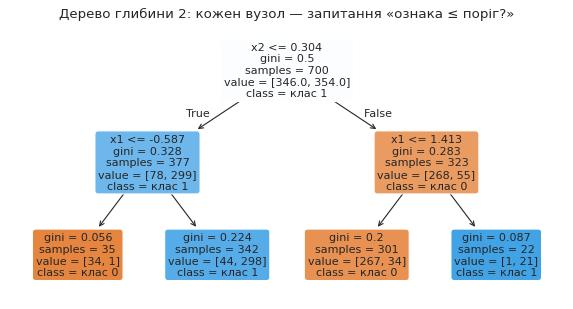

In [2]:
X, y = make_moons(n_samples=1000, noise=0.30, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)
small = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(X_tr, y_tr)
plt.figure(figsize=(9, 4.5))
plot_tree(small, feature_names=["x1", "x2"], class_names=["клас 0", "клас 1"], filled=True, rounded=True, fontsize=10)
plt.title("Дерево глибини 2: кожен вузол — запитання «ознака ≤ поріг?»"); plt.show()

## 2. Одне дерево проти лісу: межі рішень

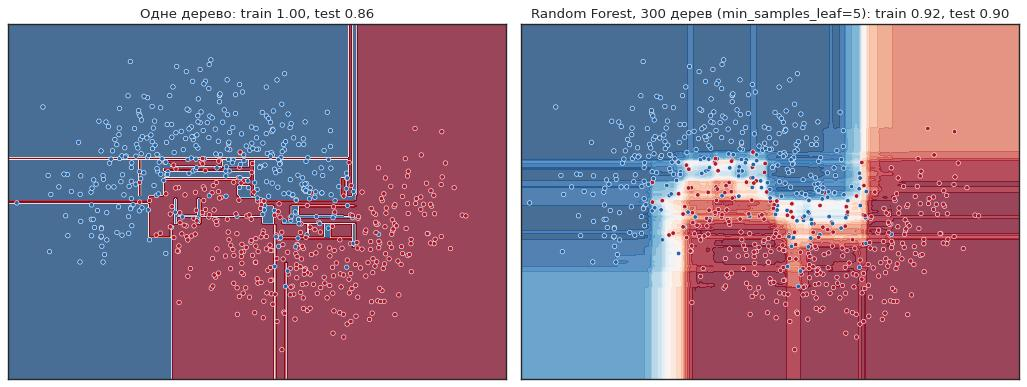

In [3]:
tree = DecisionTreeClassifier(random_state=SEED).fit(X_tr, y_tr)                          # без обмеження глибини
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)

def boundary(ax, model, title):
    xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))
    zz = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.75)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=np.where(y_tr == 1, "#b2182b", "#2166ac"), edgecolor="white", linewidth=0.5, s=16)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, m, name in [(axes[0], tree, "Одне дерево"), (axes[1], forest, "Random Forest, 300 дерев (min_samples_leaf=5)")]:
    tr, te = accuracy_score(y_tr, m.predict(X_tr)), accuracy_score(y_te, m.predict(X_te))
    boundary(ax, m, f"{name}: train {tr:.2f}, test {te:.2f}")
plt.tight_layout(); plt.show()

Одне дерево має 100 % на train, але його межа «рвана»: вона обводить окремі шумові точки. Ліс усереднює 300 різних дерев, тому межа плавна: на train він «гірший» (не запам'ятовує шум), а на test кращий. Параметр `min_samples_leaf=5` не дає деревам будувати листки під одиничні точки.

## 3. Як працює Random Forest
1. **Bootstrap:** кожне дерево навчається на власній випадковій вибірці з поверненням, приблизно 63 % унікальних об'єктів.
2. **Випадкові ознаки:** у кожному розбитті дерево обирає найкращу ознаку лише з випадкової підмножини (`max_features`, для класифікації √n ознак). Тому дерева різні.
3. **Голосування:** у класифікації перемагає клас, за який проголосувала більшість дерев (у scikit-learn усереднюються ймовірності); у регресії беруть середнє прогнозів.

Помилки окремих дерев різні й частково компенсують одна одну, тому ансамбль стабільніший за будь-яке з дерев.

## 4. Реальні дані: скільки дерев потрібно (набір Wine, 13 ознак, 3 класи)

In [4]:
wine = load_wine()
Xw, yw = wine.data, wine.target
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
tree_cv = cross_val_score(DecisionTreeClassifier(random_state=SEED), Xw, yw, cv=cv)
rows = []
for n in [1, 3, 5, 10, 25, 50, 100, 200, 400]:
    s = cross_val_score(RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1), Xw, yw, cv=cv)
    rows.append({"дерев": n, "accuracy (CV)": s.mean(), "std": s.std()})
nt = pd.DataFrame(rows)
print(f"Одне дерево рішень: CV accuracy = {tree_cv.mean():.3f} ± {tree_cv.std():.3f}")
nt.round(3)

Одне дерево рішень: CV accuracy = 0.916 ± 0.025


,дерев,accuracy (CV),std
0,1,0.860,0.050
1,3,0.933,0.048
2,5,0.944,0.039
3,10,0.972,0.030
4,25,0.972,0.018
5,50,0.978,0.011
6,100,0.983,0.014
7,200,0.978,0.011
8,400,0.983,0.014


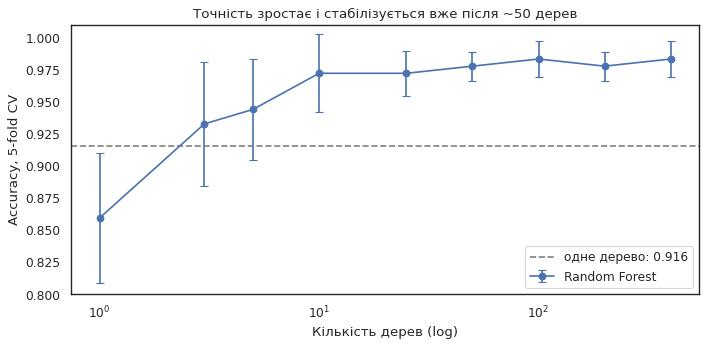

In [5]:
plt.figure(figsize=(9, 4.5))
plt.errorbar(nt["дерев"], nt["accuracy (CV)"], yerr=nt["std"], marker="o", capsize=4, label="Random Forest")
plt.axhline(tree_cv.mean(), color="gray", ls="--", label=f"одне дерево: {tree_cv.mean():.3f}")
plt.xscale("log"); plt.xlabel("Кількість дерев (log)"); plt.ylabel("Accuracy, 5-fold CV"); plt.ylim(0.8, 1.01)
plt.title("Точність зростає і стабілізується вже після ~50 дерев"); plt.legend(); plt.tight_layout(); plt.show()

## 5. Голосування для одного об'єкта та важливість ознак

Random Forest (100 дерев) на test: 1.000
Об'єкт №44: справжній клас 0; голоси дерев за класи 0/1/2: [48, 42, 10] → ліс обирає клас 0


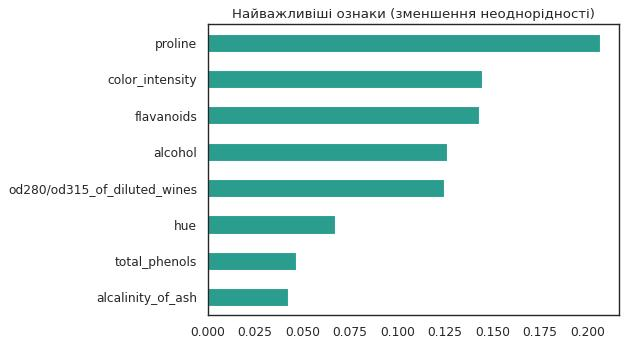

In [6]:
Xa, Xb, ya, yb = train_test_split(Xw, yw, test_size=0.3, stratify=yw, random_state=SEED)
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1).fit(Xa, ya)
print(f"Random Forest (100 дерев) на test: {accuracy_score(yb, rf.predict(Xb)):.3f}")
# знайдемо об'єкт, щодо якого дерева не одностайні
votes_all = np.array([t.predict(Xb) for t in rf.estimators_]).astype(int)   # (дерева, об'єкти)
agree = (votes_all == votes_all.mean(0).round()).mean(0)
i = int(np.argmin(np.where(agree < 1, agree, 2)))
counts = np.bincount(votes_all[:, i], minlength=3)
print(f"Об'єкт №{i}: справжній клас {yb[i]}; голоси дерев за класи 0/1/2: {counts.tolist()} → ліс обирає клас {rf.predict(Xb[i:i+1])[0]}")
imp = pd.Series(rf.feature_importances_, index=wine.feature_names).sort_values().tail(8)
imp.plot.barh(figsize=(8, 4.5), color="#2a9d8f"); plt.title("Найважливіші ознаки (зменшення неоднорідності)"); plt.tight_layout(); plt.show()

## 6. Висновки

1. **Random Forest — ансамбль дерев рішень.** Кожне дерево навчається на власній bootstrap-вибірці й у кожному розбитті бачить лише випадкову частину ознак. Тому дерева різні, а їхні помилки частково компенсуються.
2. **Одне дерево схильне до перенавчання.** На даних «два півмісяці» воно має 100 % на train, але 86 % на test. Ліс зі 300 дерев має 92 % на train і 90 % на test: він не запам'ятовує шум і краще узагальнює.
3. **Результат формується голосуванням** (у регресії — усередненням). У прикладі на один об'єкт набору Wine 48 дерев проголосували за клас 0, 42 за клас 1 і 10 за клас 2. Ліс обрав клас 0, і це правильна відповідь, хоча майже половина дерев помилилась.
4. **Кількість дерев:** одне дерево дає 91.6 % (CV), 10 дерев 97.2 %, 50–100 дерев близько 98 %. Далі точність стабілізується, а зростає лише час обчислень. Типове значення — 100–300 дерев.
5. **Для чого використовують:** класифікація й регресія на табличних даних (оцінка ризиків, діагностика, прогноз відтоку клієнтів, виявлення аномалій). Переваги: висока точність «з коробки», стійкість до шуму й викидів, не потребує масштабування ознак, дає оцінку важливості ознак. Обмеження: модель менш прозора, ніж одне дерево, і повільніша на дуже великих даних.